# TherMAM-NeRF: Generalizable 3D Breast Reconstruction from Radiometric TIFFs

**Inputs:** 5-view radiometric TIFF files (absolute °C) + UNet binary segmentation masks  
**Output:** 3D occupancy volume + 3D thermal surface  

### Architecture Overview
- **Siamese Feature Encoder** — shared-weight CNN extracts spatial features from each of the 5 thermal views
- **pixelNeRF-style conditioning** — for any 3D query point, bilinearly samples features from each view's feature map and mean/variance pools them
- **TherMAM-NeRF MLP** — takes (positional encoding + aggregated features) → predicts (σ density, T temperature)
- **Differentiable Ray Marcher** — renders density and temperature projections back to 2D for self-supervised training
- **Loss** — Dice loss on rendered mask vs GT mask + MSE on rendered thermal vs GT TIFF

> SE(3) pose correction is intentionally **excluded** from this implementation.  
> With only 5 views and a small dataset, joint pose+weight optimisation diverges reliably.  
> Camera angles are treated as fixed at the 5 canonical positions.


## 1. Imports & Configuration

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import os
import json
import math
import glob
import numpy as np
import tifffile
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from skimage.measure import marching_cubes
import matplotlib.pyplot as plt
import matplotlib
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
import plotly.graph_objects as go
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Paths ────────────────────────────────────────────────────────────────────
# DMR-IR dataset root — adjust to your local path
TIFF_DIR         = '../data/organized_by_patient'
UNET_DIR         = '../data/organized_by_patient_unet'
OUTPUT_DIR       = './thermamnerf_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = {
    # Data
    'img_size'        : 128,        # resize all inputs to this
    'n_views'         : 5,
    'view_angles_deg' : [-90, -45, 0, 45, 90],  # RL RO F LO LL
    'view_names'      : ['RL', 'RO', 'F', 'LO', 'LL'],

    # Encoder
    'feat_channels'   : 32,         # output channels of Siamese encoder

    # NeRF MLP
    'pos_enc_L'       : 8,          # positional encoding levels for xyz
    'mlp_hidden'      : 256,
    'mlp_layers'      : 6,

    # Ray marcher
    'n_samples'       : 64,         # stratified samples per ray
    'near'            : 0.0,
    'far'             : 1.0,
    'density_scale'   : 10.0,       # scale sigma before transmittance (sharpness)

    # Frequency schedule (coarse-to-fine)
    'freq_warmup_epochs': 30,       # epochs to ramp from L=2 → L=pos_enc_L

    # Training
    'batch_size'      : 1,          # patients per batch (small dataset)
    'n_epochs'        : 200,
    'lr'              : 5e-4,
    'lambda_dice'     : 1.0,
    'lambda_bg'       : 1.0,
    'lambda_thermal'  : 0.0,
    'lambda_tv'       : 0.005,      # total variation smoothness on density

    # Output
    'mc_threshold'    : 0.3,        # marching cubes density threshold
    'mc_resolution'   : 128,        # grid resolution for MC extraction
}
print('Config loaded.')


Using device: cuda
Config loaded.


## 2. Data Loading

Loads radiometric TIFFs (absolute °C) and UNet binary masks per patient.  
If pre-generated masks exist on disk they are loaded directly.  
If not, the frozen UNet is called at runtime.


In [2]:
# ── Optional: frozen UNet for on-the-fly mask generation ─────────────────
# If you already have mask PNGs on disk, set USE_PRECOMPUTED_MASKS = True
USE_PRECOMPUTED_MASKS = True


def load_tiff_celsius(path: str, target_size: int) -> np.ndarray:
    """Load a radiometric TIFF and return absolute temperature array (H, W)."""
    arr = tifffile.imread(path).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]            # some TIFFs are stored as (H,W,1)
    img = Image.fromarray(arr, mode='F')
    img = img.resize((target_size, target_size), Image.BILINEAR)
    return np.array(img, dtype=np.float32)


def load_mask(path: str, target_size: int) -> np.ndarray:
    """Load a UNet binary mask PNG. Returns float32 (H,W) in {0,1}."""
    img = Image.open(path).convert('L')
    img = img.resize((target_size, target_size), Image.NEAREST)
    arr = np.array(img, dtype=np.float32) / 255.0
    return (arr > 0.5).astype(np.float32)


def normalize_thermal(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise per-patient to [0,1] while keeping absolute temps
    accessible separately. Returns (normalised, min, max)."""
    tmin, tmax = arr.min(), arr.max()
    normed = (arr - tmin) / (tmax - tmin + 1e-6)
    return normed, tmin, tmax


def get_view_key(filename):
    n = filename.lower()
    if 'right later' in n: return 'RL'
    if 'right obli'  in n: return 'RO'
    if 'frontal' in n or 'anterior' in n: return 'F'
    if 'left obliq'  in n: return 'LO'
    if 'left later'  in n: return 'LL'
    return None

def discover_patients_split(tiff_base, unet_base):
    from pathlib import Path
    tb = Path(tiff_base)
    ub = Path(unet_base)
    pd_ = {}
    
    for tp in tb.rglob('*.tiff'):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {'tiffs': {}, 'masks': {}}
        pd_[key]['tiffs'][vk] = tp
        
    for mp in ub.rglob('*.png'):
        parts = mp.relative_to(ub).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key in pd_:
            pd_[key]['masks'][vk] = mp
            
    patients = []
    for (pid, lab), d in pd_.items():
        if len(d['tiffs']) == 5 and len(d['masks']) == 5:
            patients.append({
                'id'   : pid,
                'tiffs': d['tiffs'],
                'masks': d['masks'],
            })
        else:
            print(f'  [SKIP] {pid} — missing views')
            
    patients.sort(key=lambda p: int(p['id'].split('_')[-1]) if '_' in p['id'] else p['id'])
    print(f'Found {len(patients)} complete patients.')
    return patients

patients = discover_patients_split(TIFF_DIR, UNET_DIR)

  [SKIP] Patient_384 — missing views
  [SKIP] Patient_23 — missing views
  [SKIP] Patient_141 — missing views
  [SKIP] Patient_109 — missing views
  [SKIP] Patient_394 — missing views
  [SKIP] Patient_160 — missing views
  [SKIP] Patient_163 — missing views
  [SKIP] Patient_18 — missing views
  [SKIP] Patient_104 — missing views
  [SKIP] Patient_258 — missing views
  [SKIP] Patient_105 — missing views
  [SKIP] Patient_189 — missing views
  [SKIP] Patient_51 — missing views
  [SKIP] Patient_243 — missing views
  [SKIP] Patient_193 — missing views
Found 122 complete patients.


## 3. Dataset & DataLoader

Train: 97 | Val: 25
tiffs_norm: torch.Size([5, 128, 128]) | masks: torch.Size([5, 128, 128]) | tiffs_abs range: 20.085269927978516 — 34.22700881958008 °C


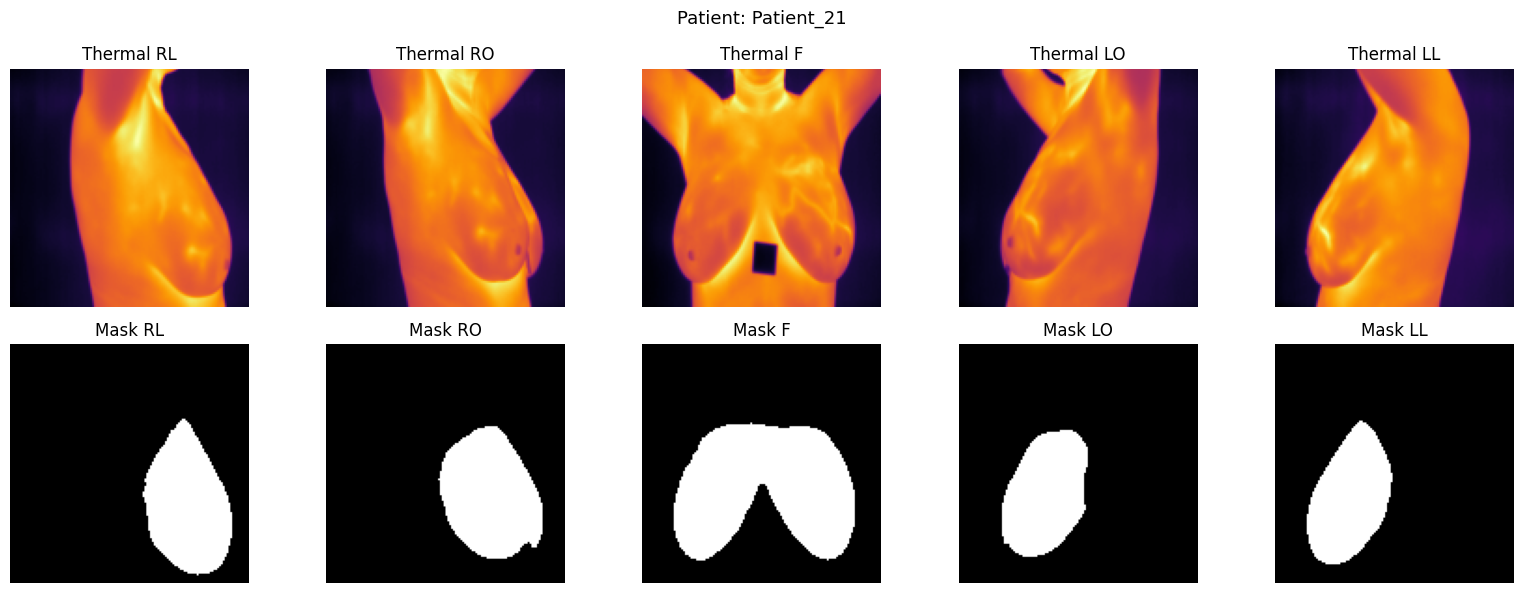

In [3]:
class BreastThermDataset(Dataset):
    """
    Returns per-patient tensors:
      tiffs_norm  : (5, H, W)  normalised thermal [0,1]
      tiffs_abs   : (5, H, W)  absolute temperature °C
      masks       : (5, H, W)  binary UNet masks {0,1}
      tmin, tmax  : scalars for inverting normalisation later
    """
    def __init__(self, patient_list: list, cfg: dict):
        self.patients = patient_list
        self.cfg = cfg
        self.S = cfg['img_size']
        self.view_names = cfg['view_names']

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        p = self.patients[idx]
        tiffs_norm, tiffs_abs, masks = [], [], []
        tmins, tmaxs = [], []

        for v in self.view_names:
            raw   = load_tiff_celsius(str(p['tiffs'][v]), self.S)
            normd, tmin, tmax = normalize_thermal(raw)
            mask  = load_mask(str(p['masks'][v]), self.S)

            tiffs_norm.append(normd)
            tiffs_abs.append(raw)
            masks.append(mask)
            tmins.append(tmin)
            tmaxs.append(tmax)

        return {
            'patient_id' : p['id'],
            'tiffs_norm' : torch.tensor(np.stack(tiffs_norm), dtype=torch.float32),  # (5,H,W)
            'tiffs_abs'  : torch.tensor(np.stack(tiffs_abs),  dtype=torch.float32),  # (5,H,W)
            'masks'      : torch.tensor(np.stack(masks),      dtype=torch.float32),  # (5,H,W)
            'tmin'       : torch.tensor(tmins, dtype=torch.float32),                 # (5,)
            'tmax'       : torch.tensor(tmaxs, dtype=torch.float32),                 # (5,)
        }


# ── Train/val split (80/20) ──────────────────────────────────────────────────
import random
random.seed(42)
random.shuffle(patients)
split = int(0.8 * len(patients))
train_patients = patients[:split]
val_patients   = patients[split:]
print(f'Train: {len(train_patients)} | Val: {len(val_patients)}')

train_ds = BreastThermDataset(train_patients, CFG)
val_ds   = BreastThermDataset(val_patients,   CFG)

train_dl = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                      num_workers=0, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                      num_workers=0, pin_memory=False)

# ── Quick sanity-check ───────────────────────────────────────────────────────
if len(train_ds) > 0:
    sample = train_ds[0]
    print('tiffs_norm:', sample['tiffs_norm'].shape,
          '| masks:', sample['masks'].shape,
          '| tiffs_abs range:', sample['tiffs_abs'].min().item(),
          '—', sample['tiffs_abs'].max().item(), '°C')

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    for i, v in enumerate(CFG['view_names']):
        axes[0, i].imshow(sample['tiffs_norm'][i], cmap='inferno')
        axes[0, i].set_title(f'Thermal {v}')
        axes[0, i].axis('off')
        axes[1, i].imshow(sample['masks'][i], cmap='gray')
        axes[1, i].set_title(f'Mask {v}')
        axes[1, i].axis('off')
    plt.suptitle(f'Patient: {sample["patient_id"]}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Siamese Feature Encoder

A lightweight shared-weight CNN processes each thermal view independently.
For each 3D query point, we project it into each view's image plane,
bilinearly sample the feature map, then pool across all 5 views.
This is the pixelNeRF conditioning mechanism.


In [4]:
class SiameseEncoder(nn.Module):
    """
    Shared-weight CNN that maps a single thermal view (H,W) → feature map (C,H,W).
    Takes concatenated [normalised_tiff, mask] as 2-channel input.
    """
    def __init__(self, out_channels: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2,  16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, 1),                        # (C, H, W)
        )

    def forward(self, tiff_norm: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        tiff_norm, mask: (B, H, W)
        returns: (B, C, H, W)
        """
        x = torch.stack([tiff_norm, mask], dim=1)  # (B, 2, H, W)
        return self.net(x)


def project_and_sample(pts_3d: torch.Tensor,
                        feat_maps: torch.Tensor,
                        view_angles_rad: torch.Tensor) -> torch.Tensor:
    """
    For each 3D point, project into each view's image plane and
    bilinearly sample the feature map.

    pts_3d       : (B, N, 3)  — query points in normalised [-1,1] space
    feat_maps    : (B, V, C, H, W)  — one feature map per view
    view_angles_rad : (V,)  — Y-axis rotation angle per view

    returns: aggregated_features (B, N, 2*C)
             — channel-wise [mean, std] across views (permutation-invariant)
    """
    B, N, _ = pts_3d.shape
    V, C    = feat_maps.shape[1], feat_maps.shape[2]

    per_view_feats = []
    for v in range(V):
        theta = view_angles_rad[v]         # scalar
        cos_t = torch.cos(theta)
        sin_t = torch.sin(theta)

        # Rotate points to view v's camera frame (Y-axis rotation)
        x  = pts_3d[..., 0]
        y  = pts_3d[..., 1]
        z  = pts_3d[..., 2]
        xr =  cos_t * x + sin_t * z
        yr =  y
        # zr = -sin_t * x + cos_t * z  # depth in cam frame (not needed for projection)

        # Orthographic projection: (xr, yr) are already the 2D pixel coords in [-1,1]
        # (We use normalised coords so grid_sample works directly)
        grid = torch.stack([xr, yr], dim=-1)  # (B, N, 2)
        grid = grid.unsqueeze(1)               # (B, 1, N, 2)  — 1-pixel-tall "scanline"


        fmap = feat_maps[:, v]                 # (B, C, H, W)
        # Clamp to valid image range to prevent zero-padding from feeding OOD zero vectors to MLP
        grid = grid.clamp(-1, 1)

        # grid_sample: output (B, C, 1, N)
        sampled = F.grid_sample(fmap, grid, mode='bilinear',
                                padding_mode='zeros', align_corners=True)
        sampled = sampled.squeeze(2)           # (B, C, N)
        sampled = sampled.permute(0, 2, 1)     # (B, N, C)
        per_view_feats.append(sampled)

    stacked = torch.stack(per_view_feats, dim=2)  # (B, N, V, C)
    mu  = stacked.mean(dim=2)                      # (B, N, C)
    var = stacked.var(dim=2)                       # (B, N, C)  — permutation invariant
    return torch.cat([mu, var], dim=-1)            # (B, N, 2C)


## 5. Positional Encoding & Coarse-to-Fine Schedule

In [5]:
def positional_encoding(x: torch.Tensor, L: int, alpha: float = None) -> torch.Tensor:
    """
    Fourier positional encoding for coordinate tensor x (B, N, D).
    Encodes each dimension with L frequency bands.
    alpha controls the coarse-to-fine windowing (None = full bandwidth).

    Output shape: (B, N, D * 2 * L)
    """
    freqs = 2.0 ** torch.arange(L, dtype=torch.float32, device=x.device)  # (L,)
    x_freq = x.unsqueeze(-1) * freqs * math.pi    # (B, N, D, L)
    
    sin_part = torch.sin(x_freq)
    cos_part = torch.cos(x_freq)

    # Coarse-to-fine windowing (from the doc, Section 6.1)
    if alpha is not None:
        k = torch.arange(L, dtype=torch.float32, device=x.device)
        w = torch.clamp(alpha - k, 0.0, 1.0)      # ramp window (L,)
        w = 0.5 * (1 - torch.cos(math.pi * w))    # smooth cosine (L,)
        w = w.view(1, 1, 1, L)                    # broadcast to (B, N, D, L)
        sin_part = sin_part * w
        cos_part = cos_part * w

    enc = torch.cat([sin_part, cos_part], dim=-1)  # (B, N, D, 2L)
    return enc.flatten(-2)   # (B, N, D * 2L)


def get_alpha(epoch: int, warmup_epochs: int, L: int) -> float:
    """Linearly ramp alpha from 0 → L over warmup_epochs."""
    return min(L * epoch / max(warmup_epochs, 1), float(L))


# Quick shape check
dummy = torch.zeros(2, 100, 3)
enc   = positional_encoding(dummy, L=8, alpha=4.0)
print(f'Positional encoding output shape: {enc.shape}')  # expect (2, 100, 48)

Positional encoding output shape: torch.Size([2, 100, 48])


## 6. TherMAM-NeRF MLP

In [6]:
class ThermamNeRFMLP(nn.Module):
    """
    Maps (positional_encoding(xyz) + siamese_features) → (sigma, T_normalised)

    sigma : density / occupancy (>=0, passed through softplus)
    T     : normalised temperature in [0,1]
    """
    def __init__(self, pos_enc_dim: int, feat_dim: int,
                 hidden: int = 256, n_layers: int = 6):
        super().__init__()
        in_dim  = pos_enc_dim + feat_dim
        layers  = [nn.Linear(in_dim, hidden), nn.ReLU(inplace=True)]

        for i in range(n_layers - 2):
            # Skip connection at halfway point (like NeRF paper)
            if i == n_layers // 2 - 2:
                layers += [nn.Linear(hidden + in_dim, hidden), nn.ReLU(inplace=True)]
            else:
                layers += [nn.Linear(hidden, hidden), nn.ReLU(inplace=True)]

        self.layers  = nn.ModuleList()
        self.skip_at = n_layers // 2 - 1
        prev = in_dim
        for i in range(n_layers - 1):
            if i == self.skip_at:
                self.layers.append(nn.Linear(prev + in_dim, hidden))
            else:
                self.layers.append(nn.Linear(prev, hidden))
            prev = hidden

        self.sigma_head = nn.Linear(hidden, 1)   # density
        self.temp_head  = nn.Linear(hidden, 1)   # temperature

    def forward(self, pe: torch.Tensor, feat: torch.Tensor) -> tuple:
        """
        pe   : (B, N, pos_enc_dim)
        feat : (B, N, feat_dim)
        returns sigma (B,N,1), T_norm (B,N,1)
        """
        x0 = torch.cat([pe, feat], dim=-1)   # (B, N, in_dim)
        h  = x0
        for i, layer in enumerate(self.layers):
            if i == self.skip_at:
                h = torch.cat([h, x0], dim=-1)
            h = F.relu(layer(h), inplace=True)

        sigma  = F.softplus(self.sigma_head(h))     # (B, N, 1)  density >= 0
        T_norm = torch.sigmoid(self.temp_head(h))   # (B, N, 1)  in (0,1)
        return sigma, T_norm


# ── Instantiate ──────────────────────────────────────────────────────────────
L        = CFG['pos_enc_L']
pos_dim  = 3 * 2 * L                              # xyz * (sin+cos) * L
feat_dim = CFG['feat_channels'] * 2               # mean + var across views

encoder  = SiameseEncoder(out_channels=CFG['feat_channels']).to(DEVICE)
mlp      = ThermamNeRFMLP(pos_enc_dim=pos_dim,
                           feat_dim=feat_dim,
                           hidden=CFG['mlp_hidden'],
                           n_layers=CFG['mlp_layers']).to(DEVICE)


n_params = sum(p.numel() for p in list(encoder.parameters()) + list(mlp.parameters()))
print(f'Total parameters: {n_params:,}')


Total parameters: 336,690


## 7. Differentiable Ray Marcher

Casts a ray through the NeRF volume for each pixel in each view.
Integrates (σ, T) along each ray using the transmittance formulation
from the Pennes bioheat document Section 4.


In [7]:
def get_rays(H: int, W: int, angle_deg: float, device) -> tuple:
    """
    Build ray origins and directions for a single view defined by Y-axis
    rotation angle_deg. We use an orthographic camera model aligned to
    the breast coordinate system.

    Returns:
        rays_o : (H*W, 3)  ray origins (on a fronto-parallel plane at z=-1)
        rays_d : (H*W, 3)  ray directions (pointing into the volume)
    """
    theta = math.radians(angle_deg)
    # Camera sits at (sin θ, 0, -cos θ) * far, looks toward origin
    cam_dir = torch.tensor([-math.sin(theta), 0.0,  math.cos(theta)],
                           device=device)             # into the scene
    # Pixel grid in [-1,1]
    ys = torch.linspace(-1, 1, H, device=device)
    xs = torch.linspace(-1, 1, W, device=device)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')  # (H,W)

    # Ray origins: fronto-parallel plane perpendicular to cam_dir
    # Right vector: perpendicular to cam_dir in XZ plane, then rotated
    right = torch.tensor([math.cos(theta), 0.0, math.sin(theta)], device=device)
    up    = torch.tensor([0.0, 1.0, 0.0], device=device)

    # Each pixel origin = grid_x * right + grid_y * up  (no depth offset needed
    # for orthographic; ray marches along cam_dir)
    origins = (grid_x.flatten().unsqueeze(1) * right.unsqueeze(0) +
               grid_y.flatten().unsqueeze(1) * up.unsqueeze(0))       # (H*W, 3)

    dirs = cam_dir.unsqueeze(0).expand(H * W, -1)                     # (H*W, 3)
    return origins, dirs


def volume_render(sigma: torch.Tensor, T_field: torch.Tensor,
                  deltas: torch.Tensor, density_scale: float) -> tuple:
    """
    Numerical volume rendering via transmittance.

    sigma    : (R, N)  density along each ray
    T_field  : (R, N)  temperature along each ray
    deltas   : (N,)    step sizes
    density_scale : sharpness multiplier on sigma

    Returns:
        rendered_mask : (R,)   accumulated opacity in [0,1]
        rendered_temp : (R,)   expected temperature in [0,1]
    """
    sigma   = sigma * density_scale
    alpha   = 1.0 - torch.exp(-sigma * deltas.unsqueeze(0))    # (R, N)
    # Exclusive transmittance: T(t_j) = prod_{k<j} (1 - alpha_k)
    T_trans = torch.cumprod(
        torch.cat([torch.ones(alpha.shape[0], 1, device=alpha.device),
                   1.0 - alpha[:, :-1] + 1e-10], dim=1), dim=1)   # (R, N)
    weights = alpha * T_trans                                      # (R, N)

    rendered_mask = weights.sum(dim=1)                             # (R,)
    rendered_temp = (weights * T_field).sum(dim=1)                 # (R,)
    # Normalise temp by accumulated weight to get expected value
    opacity_mask  = (rendered_mask.detach() > 0.05).float()
    rendered_temp = (rendered_temp / (rendered_mask.detach() + 1e-6)) * opacity_mask
    return rendered_mask, rendered_temp


@torch.no_grad()
def render_view(encoder, mlp, tiffs_norm, masks, view_idx, cfg, device,
                alpha=None, chunk=2048):
    """
    Full rendering of a single view for one patient (no gradient).
    Used for validation and visualisation.
    Returns rendered_mask, rendered_temp both (H, W).
    """
    H = W = cfg['img_size']
    angle = cfg['view_angles_deg'][view_idx]
    view_angles_rad = torch.tensor(
        [math.radians(a) for a in cfg['view_angles_deg']], device=device)

    # Build feature maps for all views — add batch dim
    feat_maps = []
    for v in range(cfg['n_views']):
        fm = encoder(tiffs_norm[v:v+1], masks[v:v+1])   # (1, C, H, W)
        feat_maps.append(fm)
    feat_maps = torch.stack(feat_maps, dim=1)             # (1, V, C, H, W)

    rays_o, rays_d = get_rays(H, W, angle, device)        # (H*W, 3)
    near, far      = cfg['near'], cfg['far']
    n_samples      = cfg['n_samples']
    t_vals         = torch.linspace(near, far, n_samples, device=device)
    deltas         = torch.cat([t_vals[1:] - t_vals[:-1],
                                torch.tensor([1e-3], device=device)])

    all_mask, all_temp = [], []
    for i in range(0, rays_o.shape[0], chunk):
        ro = rays_o[i:i+chunk]                             # (R, 3)
        rd = rays_d[i:i+chunk]
        pts = ro.unsqueeze(1) + t_vals.view(1, -1, 1) * rd.unsqueeze(1)  # (R,N,3)
        pts = pts.unsqueeze(0)                             # (1, R, N, 3)
        R_  = pts.shape[1]
        pts_flat = pts.reshape(1, -1, 3)                  # (1, R*N, 3)

        pe   = positional_encoding(pts_flat, L=cfg['pos_enc_L'], alpha=alpha)
        feat = project_and_sample(pts_flat, feat_maps, view_angles_rad)
        sigma, T_pred = mlp(pe, feat)                     # (1, R*N, 1)
        sigma  = sigma.squeeze(-1).squeeze(0).reshape(R_, n_samples)
        T_pred = T_pred.squeeze(-1).squeeze(0).reshape(R_, n_samples)

        rm, rt = volume_render(sigma, T_pred, deltas, cfg['density_scale'])
        all_mask.append(rm)
        all_temp.append(rt)

    rendered_mask = torch.cat(all_mask).reshape(H, W)
    rendered_temp = torch.cat(all_temp).reshape(H, W)
    return rendered_mask, rendered_temp

## 8. Loss Functions

In [8]:
def dice_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Sørensen–Dice loss for binary masks."""
    pred   = pred.flatten()
    target = target.flatten()
    inter  = (pred * target).sum()
    return 1.0 - (2.0 * inter + eps) / (pred.sum() + target.sum() + eps)

def tv_loss_3d(field: torch.Tensor) -> torch.Tensor:
    """
    Total Variation regularisation on a 3D density field (D, H, W).
    Encourages spatial smoothness and suppresses starfish artifacts.
    """
    dx = (field[1:, :, :] - field[:-1, :, :]).abs().mean()
    dy = (field[:, 1:, :] - field[:, :-1, :]).abs().mean()
    dz = (field[:, :, 1:] - field[:, :, :-1]).abs().mean()
    return dx + dy + dz

def compute_loss(rendered_masks, rendered_temps,
                 gt_masks, gt_tiffs_norm, cfg, loss_tv=0.0) -> dict:
    """
    rendered_masks  : list of (B,H,W) per view
    rendered_temps  : list of (B,H,W) per view
    gt_masks        : (B, V, H, W)
    gt_tiffs_norm   : (B, V, H, W)
    """
    loss_dice    = torch.tensor(0., device=gt_masks.device)
    loss_thermal = torch.tensor(0., device=gt_masks.device)
    loss_bg      = torch.tensor(0., device=gt_masks.device)

    for v in range(cfg['n_views']):
        pred_m  = rendered_masks[v]           # (B, H, W)
        pred_t  = rendered_temps[v]
        gt_m    = gt_masks[:, v]              # (B, H, W)
        gt_t    = gt_tiffs_norm[:, v]

        # Apply mask to thermal loss — only penalise foreground pixels
        fg      = (gt_m > 0.5)
        bg      = (gt_m <= 0.5)
        
        loss_dice    += dice_loss(pred_m, gt_m)
        if fg.any():
            loss_thermal += torch.nn.functional.mse_loss(pred_t[fg], gt_t[fg])
            
        # Explicitly penalize ANY density in the background
        if bg.any():
            loss_bg += pred_m[bg].pow(2).mean()

    loss_dice    /= cfg['n_views']
    loss_thermal /= cfg['n_views']
    loss_bg      /= cfg['n_views']

    # Combine losses (strong 1.0 weight on bg loss to crush residue)
    total = (cfg['lambda_dice']    * loss_dice +
             cfg['lambda_thermal'] * loss_thermal +
             cfg.get('lambda_tv', 0.0) * loss_tv +
             1.0 * loss_bg)

    return {'total': total, 'dice': loss_dice, 'thermal': loss_thermal, 'tv': loss_tv, 'bg': loss_bg}



## 9. Training Loop

In [9]:
def background_ray_loss(rendered_masks: list, gt_masks: torch.Tensor) -> torch.Tensor:
    loss = torch.tensor(0.0, device=gt_masks.device)
    V = gt_masks.shape[1]  # or length of rendered_masks
    for v in range(V):
        bg_pixels = (gt_masks[:, v] < 0.5)
        if bg_pixels.any():
            loss += rendered_masks[v][bg_pixels].pow(2).mean()
    return loss / V

def run_one_batch(batch, encoder, mlp, cfg, alpha, device):
    """
    Forward pass for one batch of patients.
    Returns loss dict and rendered outputs for logging.
    """
    tiffs_norm = batch['tiffs_norm'].to(device)  # (B, V, H, W)
    tiffs_abs  = batch['tiffs_abs'].to(device)
    masks      = batch['masks'].to(device)        # (B, V, H, W)
    B, V, H, W = masks.shape

    view_angles_rad = torch.tensor(
        [math.radians(a) for a in cfg['view_angles_deg']], device=device)

    # ── Build Siamese feature maps: (B, V, C, H, W) ─────────────────────────
    feat_maps = []
    for v in range(V):
        fm = encoder(tiffs_norm[:, v], masks[:, v])   # (B, C, H, W)
        feat_maps.append(fm)
    feat_maps = torch.stack(feat_maps, dim=1)         # (B, V, C, H, W)

    # ── Ray march each view ──────────────────────────────────────────────────
    rendered_masks, rendered_temps = [], []
    gt_masks_sampled, gt_tiffs_sampled = [], []
    n_s   = cfg['n_samples']
    near  = cfg['near']
    far   = cfg['far']
    t_vals = torch.linspace(near, far, n_s, device=device)
    # Add jitter for training (stratified sampling regularisation)
    noise  = torch.rand_like(t_vals) * (far - near) / n_s
    t_vals = t_vals + noise
    deltas = torch.cat([t_vals[1:] - t_vals[:-1],
                        torch.tensor([1e-3], device=device)])

    N_rays = 2048  # Memory safety chunk limit

    for v in range(V):
        angle  = cfg['view_angles_deg'][v]
        rays_o, rays_d = get_rays(H, W, angle, device)      # (H*W, 3)

        # Ray sampling to prevent OOM
        ray_indices = torch.randperm(H*W, device=device)[:N_rays]
        rays_o = rays_o[ray_indices]
        rays_d = rays_d[ray_indices]
        
        gt_m = masks[:, v].reshape(B, H*W)[:, ray_indices]
        gt_t = tiffs_norm[:, v].reshape(B, H*W)[:, ray_indices]
        
        gt_masks_sampled.append(gt_m)
        gt_tiffs_sampled.append(gt_t)

        pts = (rays_o.unsqueeze(1) +
               t_vals.view(1, -1, 1) * rays_d.unsqueeze(1)) # (N_rays, N, 3)

        # Add batch dim: (B, N_rays, N, 3)
        pts = pts.unsqueeze(0).expand(B, -1, -1, -1)
        pts_flat = pts.reshape(B, -1, 3)                    # (B, N_rays*N, 3)

        pe   = positional_encoding(pts_flat, L=cfg['pos_enc_L'], alpha=alpha)
        feat = project_and_sample(pts_flat, feat_maps, view_angles_rad)
        sigma, T_pred = mlp(pe, feat)                       # (B, N_rays*N, 1)

        sigma  = sigma.squeeze(-1).reshape(B, N_rays, n_s)
        T_pred = T_pred.squeeze(-1).reshape(B, N_rays, n_s)

        rm_list, rt_list = [], []
        for b in range(B):
            rm, rt = volume_render(sigma[b], T_pred[b], deltas,
                                   cfg['density_scale'])
            rm_list.append(rm)
            rt_list.append(rt)

        rendered_masks.append(torch.stack(rm_list))         # list of (B,N_rays)
        rendered_temps.append(torch.stack(rt_list))

    gt_masks_sampled = torch.stack(gt_masks_sampled, dim=1) # (B, V, N_rays)
    gt_tiffs_sampled = torch.stack(gt_tiffs_sampled, dim=1)

    # ── Coarse TV Loss (to avoid dense grid bottleneck) ─────────────────────
    R_tv = 16
    linspace_tv = torch.linspace(near, far, R_tv, device=device)
    zz, yy, xx = torch.meshgrid(linspace_tv, linspace_tv, linspace_tv, indexing='ij')
    pts_tv = torch.stack([xx, yy, zz], dim=-1).reshape(1, -1, 3).expand(B, -1, -1)
    pe_tv = positional_encoding(pts_tv, L=cfg['pos_enc_L'], alpha=alpha)
    feat_tv = project_and_sample(pts_tv, feat_maps, view_angles_rad)
    sigma_tv, _ = mlp(pe_tv, feat_tv)
    sigma_tv = sigma_tv.squeeze(-1).reshape(B, R_tv, R_tv, R_tv)
    
    loss_tv = torch.tensor(0., device=device)
    for b in range(B):
        loss_tv += tv_loss_3d(sigma_tv[b])
    loss_tv /= B

    loss_dict = compute_loss(rendered_masks, rendered_temps,
                             gt_masks_sampled, gt_tiffs_sampled, cfg, loss_tv=loss_tv)
    return loss_dict, rendered_masks, rendered_temps

# ── Optimiser ────────────────────────────────────────────────────────────────
params    = list(encoder.parameters()) + list(mlp.parameters())
optimiser = torch.optim.Adam(params, lr=CFG['lr'], betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=CFG['n_epochs'], eta_min=CFG['lr'] * 0.05)

# ── Resume from Checkpoint ─────────────────────────
RESUME = False
START_EPOCH = 1
ckpt_path = os.path.join(OUTPUT_DIR, 'thermamnerf_best.pth')
if RESUME and os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path)
    enc_state = {k.replace('module.', ''): v for k, v in ckpt['encoder'].items()}
    mlp_state = {k.replace('module.', ''): v for k, v in ckpt['mlp'].items()}
    encoder.load_state_dict(enc_state)
    mlp.load_state_dict(mlp_state)
    print('\n✅ Resumed weights from thermamnerf_best.pth!')
    START_EPOCH = 41
    for _ in range(START_EPOCH - 1):
        scheduler.step()

# ── Training ──────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_dice': [], 'val_thermal': []}
best_val_dice = float('inf')   # dice LOSS — lower is better

for epoch in tqdm(range(START_EPOCH, CFG['n_epochs'] + 1), desc='Training Epochs'):
    encoder.train()
    mlp.train()
    alpha = get_alpha(epoch, CFG['freq_warmup_epochs'], CFG['pos_enc_L'])

    epoch_loss = []
    for batch in tqdm(train_dl, desc=f'Epoch {epoch}/{CFG["n_epochs"]}', leave=False):
        optimiser.zero_grad()
        loss_dict, _, _ = run_one_batch(batch, encoder, mlp, CFG, alpha, DEVICE)
        loss_dict['total'].backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        optimiser.step()
        epoch_loss.append(loss_dict['total'].item())

    scheduler.step()
    mean_train = np.mean(epoch_loss)
    history['train_loss'].append(mean_train)

    # ── Validation every 10 epochs ───────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        encoder.eval()
        mlp.eval()
        val_dice_losses, val_therm_losses = [], []
        with torch.no_grad():
            for batch in val_dl:
                cfg_step = dict(CFG)
                if epoch <= 50:
                    cfg_step['lambda_thermal'] = 0.0
                else:
                    cfg_step['lambda_thermal'] = 0.01
                ld, _, _ = run_one_batch(batch, encoder, mlp, cfg_step, alpha, DEVICE)
                val_dice_losses.append(ld['dice'].item())
                val_therm_losses.append(ld['thermal'].item())

        vd = np.mean(val_dice_losses)
        vt = np.mean(val_therm_losses)
        history['val_dice'].append(vd)
        history['val_thermal'].append(vt)

        if vd < best_val_dice:
            best_val_dice = vd
            torch.save({'encoder': encoder.state_dict(),
                        'mlp':     mlp.state_dict()},
                       os.path.join(OUTPUT_DIR, 'thermamnerf_best.pth'))

        print(f'Epoch {epoch:03d}/{CFG["n_epochs"]} | '
              f'Train Loss: {mean_train:.4f} | '
              f'Val Dice Loss: {vd:.4f} (Dice: {1-vd:.4f}) | '
              f'Val Thermal MSE: {vt:.4f} | '
              f'α: {alpha:.1f}')

Training Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 001/200 | Train Loss: 0.4561 | Val Dice Loss: 0.1978 (Dice: 0.8022) | Val Thermal MSE: 0.0887 | α: 0.3


Epoch 2/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 3/200:   0%|          | 0/97 [00:00<?, ?it/s]

...

Epoch 197/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 198/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 199/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 200/200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 200/200 | Train Loss: 0.0197 | Val Dice Loss: 0.1605 (Dice: 0.8395) | Val Thermal MSE: 0.0895 | α: 8.0


## 10. Training Curves

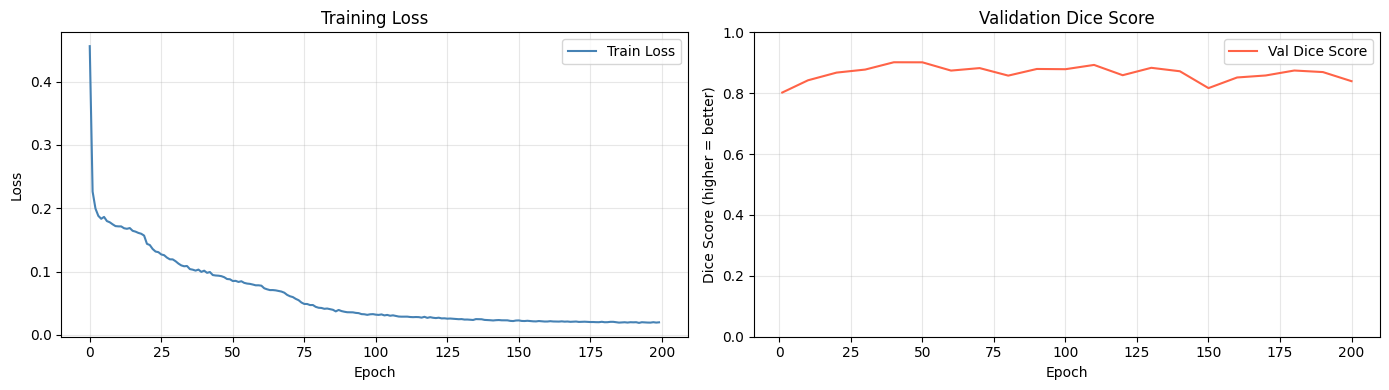

Best val Dice Score: 0.9017


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

val_epochs = [1] + list(range(10, CFG['n_epochs'] + 1, 10))
if len(val_epochs) > len(history['val_dice']):
    val_epochs = val_epochs[:len(history['val_dice'])]
elif len(history['val_dice']) > len(val_epochs):
    history['val_dice'] = history['val_dice'][:len(val_epochs)]
axes[1].plot(val_epochs, [1 - d for d in history['val_dice']],
             label='Val Dice Score', color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score (higher = better)')
axes[1].set_title('Validation Dice Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()
print(f'Best val Dice Score: {1 - best_val_dice:.4f}')


## 11. Projection Audit (Qualitative Check)
Renders all 5 views for a validation patient and compares with GT.


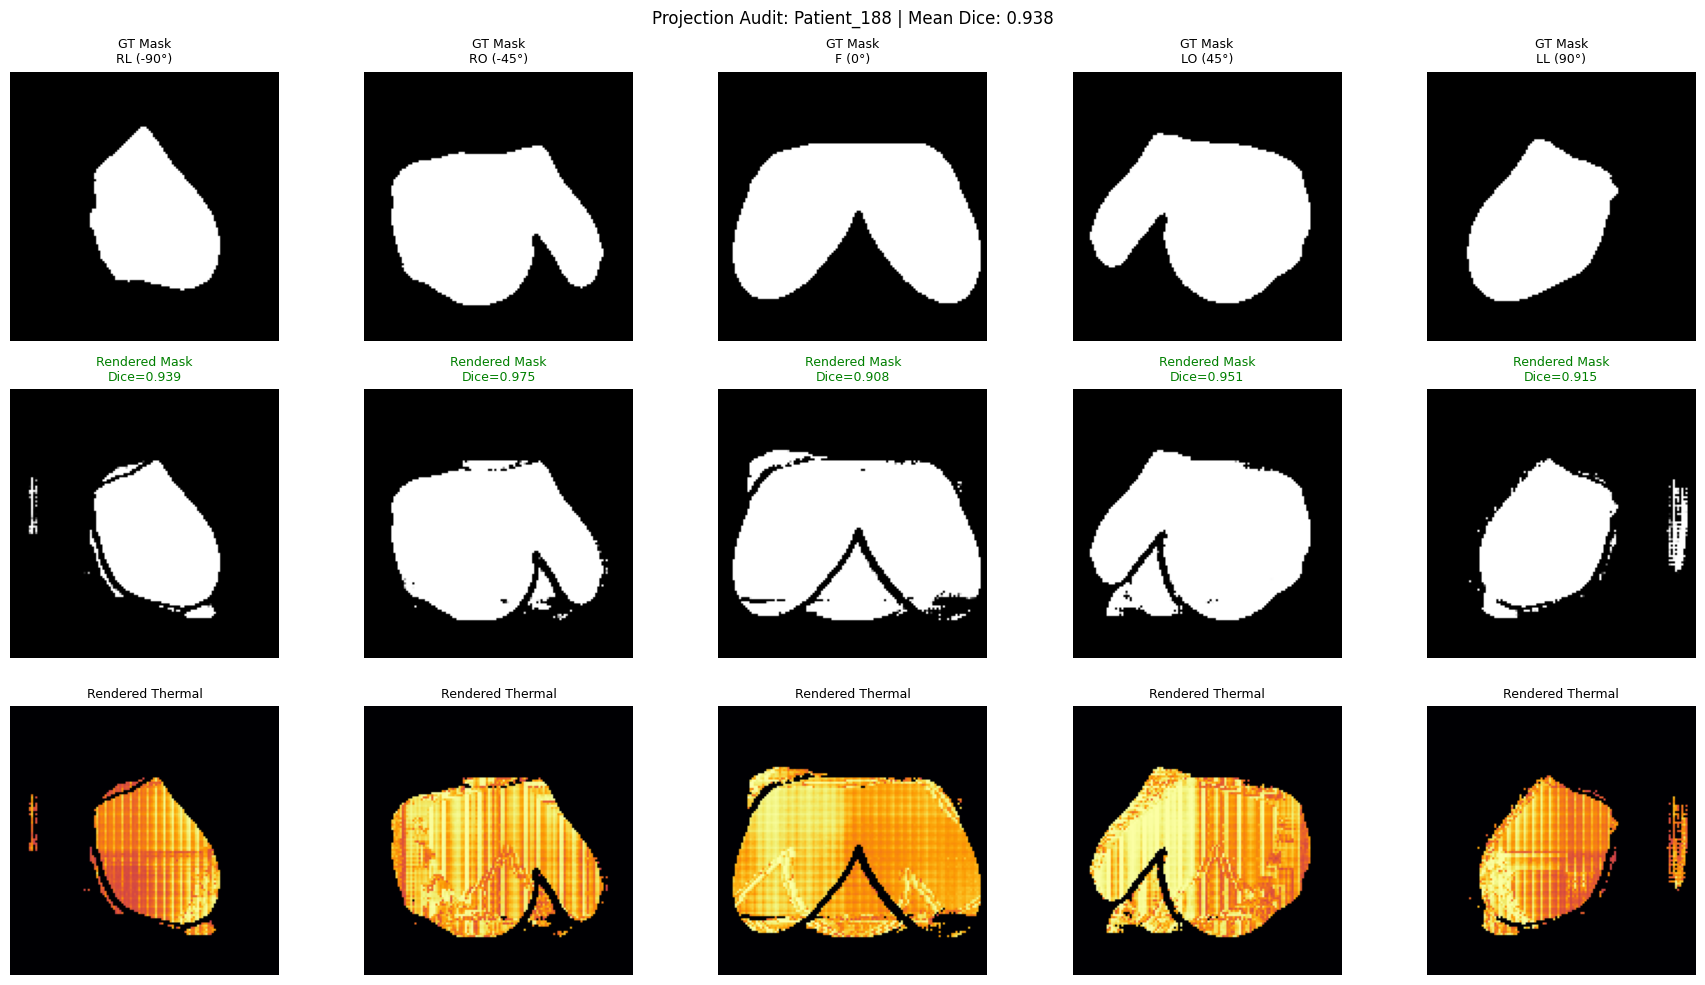

In [11]:
# Load best checkpoint
ckpt = torch.load(os.path.join(OUTPUT_DIR, 'thermamnerf_best.pth'),
                  map_location=DEVICE)
encoder.load_state_dict(ckpt['encoder'])
mlp.load_state_dict(ckpt['mlp'])
encoder.eval(); mlp.eval()

# Pick first val patient
sample      = val_ds[0]
tiffs_norm  = sample['tiffs_norm'].to(DEVICE)   # (V, H, W)
tiffs_abs   = sample['tiffs_abs'].to(DEVICE)
masks       = sample['masks'].to(DEVICE)         # (V, H, W)
patient_id  = sample['patient_id']

alpha_final = float(CFG['pos_enc_L'])   # full frequency bandwidth

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
dice_scores = []

for v, vname in enumerate(CFG['view_names']):
    angle = CFG['view_angles_deg'][v]
    rm, rt = render_view(encoder, mlp, tiffs_norm, masks, v, CFG,
                         DEVICE, alpha=alpha_final)

    gt_mask = masks[v].cpu().numpy()
    gt_temp = tiffs_norm[v].cpu().numpy()
    pred_m  = rm.cpu().numpy()
    pred_t  = rt.cpu().numpy()

    # Dice score
    pred_bin = (pred_m > 0.5).astype(np.float32)
    inter    = (pred_bin * gt_mask).sum()
    dsc      = 2 * inter / (pred_bin.sum() + gt_mask.sum() + 1e-6)
    dice_scores.append(dsc)

    axes[0, v].imshow(gt_mask, cmap='gray')
    axes[0, v].set_title(f'GT Mask\n{vname} ({angle}°)', fontsize=9)
    axes[0, v].axis('off')

    axes[1, v].imshow(pred_m, cmap='gray', vmin=0, vmax=1)
    axes[1, v].set_title(f'Rendered Mask\nDice={dsc:.3f}',
                         color='green' if dsc > 0.85 else 'red', fontsize=9)
    axes[1, v].axis('off')

    axes[2, v].imshow(pred_t, cmap='inferno', vmin=0, vmax=1)
    axes[2, v].set_title('Rendered Thermal', fontsize=9)
    axes[2, v].axis('off')

plt.suptitle(f'Projection Audit: {patient_id} | Mean Dice: {np.mean(dice_scores):.3f}',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'audit_{patient_id}.png'), dpi=120)
plt.show()


## 11.5 Diagnostic — Thermal Stripe Analysis


THERMAL STRIPE DIAGNOSTIC

RL (-90°):
  Temp range   : [0.0000, 0.9963]
  Full std     : 0.3010
  FG-only std  : 0.1176
  Col variance : 0.1607
  Row variance : 0.1411
  Dominant col freq: 0.0078 cycles/px

RO (-45°):
  Temp range   : [0.0000, 0.9989]
  Full std     : 0.4071
  FG-only std  : 0.1087
  Col variance : 0.1843
  Row variance : 0.2681
  Dominant col freq: 0.0078 cycles/px

F (0°):
  Temp range   : [0.0000, 0.9995]
  Full std     : 0.4248
  FG-only std  : 0.0809
  Col variance : 0.1494
  Row variance : 0.3195
  Dominant col freq: 0.0078 cycles/px

LO (45°):
  Temp range   : [0.0000, 1.0000]
  Full std     : 0.4222
  FG-only std  : 0.1207
  Col variance : 0.1868
  Row variance : 0.2813
  Dominant col freq: 0.0078 cycles/px

LL (90°):
  Temp range   : [0.0000, 0.9993]
  Full std     : 0.3287
  FG-only std  : 0.1213
  Col variance : 0.1697
  Row variance : 0.1687
  Dominant col freq: 0.0078 cycles/px


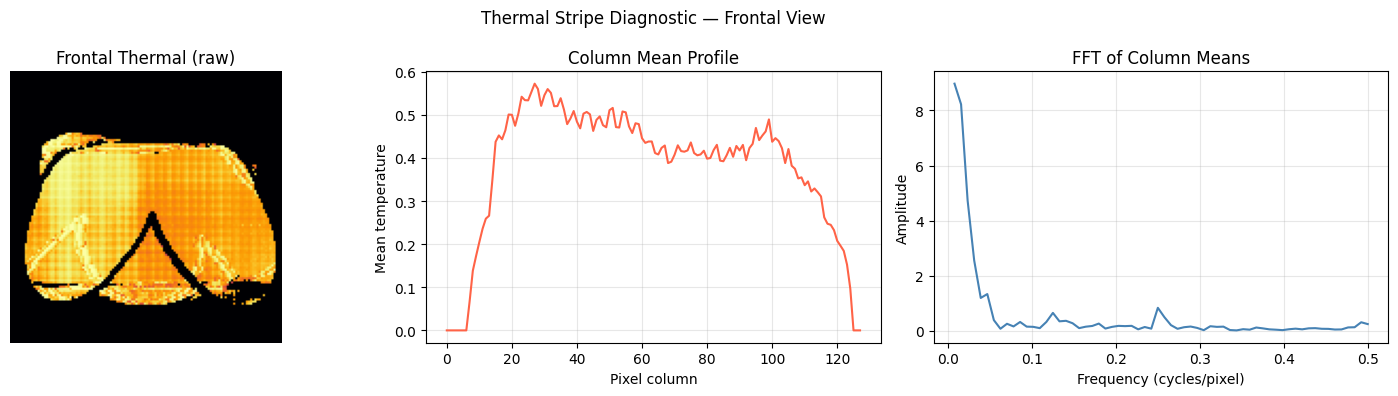

In [12]:
# ── Diagnostic: Thermal Stripe Analysis ─────────────────────────────────────
import scipy.signal

print('=' * 60)
print('THERMAL STRIPE DIAGNOSTIC')
print('=' * 60)

diag_results = {}

for v, vname in enumerate(CFG['view_names']):
    rm, rt = render_view(encoder, mlp, tiffs_norm, masks, v, CFG,
                         DEVICE, alpha=float(CFG['pos_enc_L']))

    rt_np  = rt.cpu().numpy()
    rm_np  = rm.cpu().numpy()

    # Only analyse inside the breast region
    fg_mask = (rm_np > 0.3)
    fg_vals = rt_np[fg_mask]

    t_min, t_max = rt_np.min(), rt_np.max()
    t_std        = rt_np.std()
    fg_std       = fg_vals.std() if fg_mask.any() else 0.0

    # Column-wise mean to detect vertical periodicity
    col_means    = rt_np.mean(axis=0)          # (W,)
    col_std      = col_means.std()             # high = vertical stripes

    # Row-wise mean to detect horizontal periodicity
    row_means    = rt_np.mean(axis=1)          # (H,)
    row_std      = row_means.std()             # high = horizontal stripes

    # FFT along columns to find dominant stripe frequency
    fft_col      = np.abs(np.fft.rfft(col_means - col_means.mean()))
    dominant_freq_idx = np.argmax(fft_col[1:]) + 1  # skip DC
    dominant_freq     = dominant_freq_idx / len(col_means)

    diag_results[vname] = {
        'range'         : (t_min, t_max),
        'full_std'      : t_std,
        'fg_std'        : fg_std,
        'col_std'       : col_std,
        'row_std'       : row_std,
        'dominant_freq' : dominant_freq,
    }

    print(f'\n{vname} ({CFG["view_angles_deg"][v]}°):')
    print(f'  Temp range   : [{t_min:.4f}, {t_max:.4f}]')
    print(f'  Full std     : {t_std:.4f}')
    print(f'  FG-only std  : {fg_std:.4f}')
    print(f'  Col variance : {col_std:.4f}')
    print(f'  Row variance : {row_std:.4f}')
    print(f'  Dominant col freq: {dominant_freq:.4f} cycles/px')

# Visual: plot column variance profile for frontal view
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rm_f, rt_f = render_view(encoder, mlp, tiffs_norm, masks, 2, CFG,
                          DEVICE, alpha=float(CFG['pos_enc_L']))
axes[0].imshow(rt_f.cpu().numpy(), cmap='inferno', vmin=0, vmax=1)
axes[0].set_title('Frontal Thermal (raw)')
axes[0].axis('off')

col_m = rt_f.cpu().numpy().mean(axis=0)
axes[1].plot(col_m, color='tomato')
axes[1].set_title('Column Mean Profile')
axes[1].set_xlabel('Pixel column')
axes[1].set_ylabel('Mean temperature')
axes[1].grid(alpha=0.3)

fft_m = np.abs(np.fft.rfft(col_m - col_m.mean()))
freqs = np.fft.rfftfreq(len(col_m))
axes[2].plot(freqs[1:], fft_m[1:], color='steelblue')
axes[2].set_title('FFT of Column Means')
axes[2].set_xlabel('Frequency (cycles/pixel)')
axes[2].set_ylabel('Amplitude')
axes[2].grid(alpha=0.3)

plt.suptitle('Thermal Stripe Diagnostic — Frontal View', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stripe_diagnostic.png'), dpi=120)
plt.show()



## 12. 3D Volume Extraction (Marching Cubes) & PLY Export
Evaluates the TherMAM-NeRF MLP on a dense 3D coordinate grid,
then extracts the surface mesh and colours it with predicted temperature.


In [13]:
def extract_3d_volume(encoder, mlp, tiffs_norm, masks, cfg, device,
                       resolution: int = None, chunk: int = 8192) -> tuple:
    """
    Evaluates the NeRF on a uniform 3D grid.
    Returns sigma_grid (R,R,R) and T_grid (R,R,R) as numpy arrays.
    """
    R = resolution or cfg['mc_resolution']
    linspace = torch.linspace(-1, 1, R, device=device)
    zz, yy, xx = torch.meshgrid(linspace, linspace, linspace, indexing='ij')
    pts = torch.stack([xx, yy, zz], dim=-1).reshape(1, -1, 3)  # (1, R³, 3)

    view_angles_rad = torch.tensor(
        [math.radians(a) for a in cfg['view_angles_deg']], device=device)

    # Feature maps for this patient
    feat_maps = []
    for v in range(cfg['n_views']):
        fm = encoder(tiffs_norm[v:v+1], masks[v:v+1])
        feat_maps.append(fm)
    feat_maps = torch.stack(feat_maps, dim=1)   # (1, V, C, H, W)

    alpha_final = float(cfg['pos_enc_L'])
    sigma_all, T_all = [], []
    n_pts = pts.shape[1]

    with torch.no_grad():
        for i in range(0, n_pts, chunk):
            p    = pts[:, i:i+chunk]               # (1, chunk, 3)
            pe   = positional_encoding(p, L=cfg['pos_enc_L'], alpha=alpha_final)
            feat = project_and_sample(p, feat_maps, view_angles_rad)
            sg, tp = mlp(pe, feat)                 # (1, chunk, 1)
            sigma_all.append(sg.squeeze().cpu())
            T_all.append(tp.squeeze().cpu())

    sigma_grid = torch.cat(sigma_all).reshape(R, R, R).numpy()
    T_grid     = torch.cat(T_all).reshape(R, R, R).numpy()
    return sigma_grid, T_grid


def export_ply(verts, faces, colors_rgb, filepath, temperatures=None):
    """Write a colour PLY file compatible with MeshLab / Open3D / Blender."""
    temp_prop = 'property float temperature\n' if temperatures is not None else ''
    header = (
        f"ply\nformat ascii 1.0\n"
        f"element vertex {len(verts)}\n"
        f"property float x\nproperty float y\nproperty float z\n"
        f"property uchar red\nproperty uchar green\nproperty uchar blue\n"
        f"{temp_prop}"
        f"element face {len(faces)}\n"
        f"property list uchar int vertex_indices\nend_header\n"
    )
    with open(filepath, 'w') as f:
        f.write(header)
        if temperatures is not None:
            for v, c, t in zip(verts, colors_rgb, temperatures):
                f.write(f'{v[0]:.6f} {v[1]:.6f} {v[2]:.6f} '
                        f'{int(c[0])} {int(c[1])} {int(c[2])} {t:.4f}\n')
        else:
            for v, c in zip(verts, colors_rgb):
                f.write(f'{v[0]:.6f} {v[1]:.6f} {v[2]:.6f} '
                        f'{int(c[0])} {int(c[1])} {int(c[2])}\n')
        for face in faces:
            f.write(f'3 {face[0]} {face[1]} {face[2]}\n')
    print(f'Saved PLY: {filepath}')


# ── Extract volume for first val patient ─────────────────────────────────────
print('Evaluating 3D volume grid… (takes 1-2 min on CPU)')
sigma_grid, T_grid = extract_3d_volume(
    encoder, mlp, tiffs_norm, masks, CFG, DEVICE)

# Smooth before MC to remove voxel staircasing
sigma_smooth = gaussian_filter(sigma_grid, sigma=0.8)

try:
    verts, faces, normals, _ = marching_cubes(
        sigma_smooth, level=CFG['mc_threshold'],
        spacing=(2.0/CFG['mc_resolution'],) * 3)
    # Shift verts to [-1,1] world space
    verts = verts - 1.0

    # Sample T at each vertex
    verts_idx = ((verts + 1.0) / 2.0 * (CFG['mc_resolution'] - 1)).astype(int)
    verts_idx = np.clip(verts_idx, 0, CFG['mc_resolution'] - 1)
    T_verts   = T_grid[verts_idx[:, 0], verts_idx[:, 1], verts_idx[:, 2]]

    # Restore to absolute °C for the PINN/mesh properties
    tmin_v = sample['tmin'].mean().item()
    tmax_v = sample['tmax'].mean().item()
    T_verts_abs = T_verts * (tmax_v - tmin_v) + tmin_v

    # Map to RGB using 'inferno' colormap
    cmap      = matplotlib.colormaps['inferno']
    colors    = (cmap(T_verts)[:, :3] * 255).astype(np.uint8)

    ply_path  = os.path.join(OUTPUT_DIR, f'{patient_id}_thermal.ply')
    export_ply(verts, faces, colors, ply_path, temperatures=T_verts_abs)
    print(f'Mesh: {len(verts)} vertices, {len(faces)} faces')

except Exception as e:
    print(f'Marching cubes failed (likely density too low): {e}')
    print('Try lowering mc_threshold in CFG.')

Evaluating 3D volume grid… (takes 1-2 min on CPU)
Saved PLY: ./thermamnerf_outputs/Patient_188_thermal.ply
Mesh: 56124 vertices, 112048 faces


## 13. Interactive 3D Visualisation (Plotly)
Renders the extracted thermal mesh interactively in the notebook.


In [14]:
try:
    fig3d = go.Figure(data=[
        go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0],  j=faces[:, 1],  k=faces[:, 2],
            vertexcolor=[f'rgb({c[0]},{c[1]},{c[2]})' for c in colors],
            opacity=1.0,
            name='3D Thermal Surface'
        )
    ])
    fig3d.update_layout(
        title=f'ThermamNeRF 3D Reconstruction — {patient_id}',
        scene=dict(
            xaxis_title='X (Left-Right)',
            yaxis_title='Y (Inferior-Superior)',
            zaxis_title='Z (Anterior-Posterior)',
            bgcolor='black',
        ),
        width=900, height=700,
    )
    fig3d.show()
except NameError:
    print('No mesh extracted — run Cell 12 first.')


## 14. Backward-Compatible Voxel Export
Resamples the continuous NeRF fields to a discrete grid for compatibility
with the existing `breastnet3d_v4` downstream scripts (asymmetry, PINN, etc.).


In [ ]:
def export_voxel_compatible(sigma_grid, T_grid, patient_id,
                             output_dir, tmin, tmax):
    """
    Saves numpy arrays compatible with the existing breastnet3d_v4 pipeline:
      - binary_volume.npy    : thresholded occupancy (R,R,R)
      - soft_volume.npy      : raw sigma grid (R,R,R)
      - thermal_volume.npy   : absolute temperature volume (R,R,R)
      - asymmetry.json       : left-right volume asymmetry score
    """
    pdir = os.path.join(output_dir, patient_id)
    os.makedirs(pdir, exist_ok=True)

    # Threshold to binary
    binary = (sigma_grid > CFG['mc_threshold']).astype(np.float32)

    # Restore absolute temperatures
    tmin_v = tmin.mean().item()
    tmax_v = tmax.mean().item()
    T_abs  = T_grid * (tmax_v - tmin_v) + tmin_v

    np.save(os.path.join(pdir, 'binary_volume.npy'),  binary)
    np.save(os.path.join(pdir, 'soft_volume.npy'),    sigma_grid.astype(np.float32))
    np.save(os.path.join(pdir, 'thermal_volume.npy'), T_abs.astype(np.float32))

    # Left-Right asymmetry (same formula as existing pipeline)
    R  = binary.shape[2]
    mid = R // 2
    V_left  = binary[:, :, :mid].sum()
    V_right = binary[:, :, mid:].sum()
    asym    = abs(V_left - V_right) / (V_left + V_right + 1e-6)

    with open(os.path.join(pdir, 'asymmetry.json'), 'w') as f:
        json.dump({'asymmetry_LR': float(asym),
                   'V_left': float(V_left),
                   'V_right': float(V_right)}, f, indent=2)

    print(f'Saved voxel outputs for {patient_id} → {pdir}')
    print(f'  Asymmetry LR: {asym:.4f}')
    return binary, T_abs


binary_vol, T_abs_vol = export_voxel_compatible(
    sigma_grid, T_grid, patient_id, OUTPUT_DIR,
    sample['tmin'], sample['tmax'])

# Quick cross-section visualisation
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
R = binary_vol.shape[0]
for ax, (dim, title) in zip(axes, [(0,'Axial (Z)'),(1,'Coronal (Y)'),(2,'Sagittal (X)')]):
    sl = R // 2
    if dim == 0: img = T_abs_vol[sl, :, :]
    elif dim == 1: img = T_abs_vol[:, sl, :]
    else: img = T_abs_vol[:, :, sl]
    ax.imshow(img, cmap='inferno')
    ax.set_title(f'{title} slice')
    ax.axis('off')
plt.suptitle(f'3D Thermal Cross-Sections — {patient_id}', fontsize=12)
plt.tight_layout()
plt.show()
